In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
acc_range = 2
gyro_range = 250

In [ ]:
dataset_path = r'C:/_/datasets'
headers = ['Ax', 'Ay', 'Az', 'Gx', 'Gy', 'Gz']

In [4]:
df_vertical = []
vertical_path = os.path.join(dataset_path, 'vertical')

for file in os.listdir(vertical_path):
    if file.endswith('.csv'):
        path = os.path.join(vertical_path, file)
        df = pd.read_csv(path, header=None)
        df.columns = headers
        df_vertical.append(df)

In [5]:
df_horizontal = []
horizontal_path = os.path.join(dataset_path, 'horizontal')

for file in os.listdir(horizontal_path):
    if file.endswith('.csv'):
        path = os.path.join(horizontal_path, file)
        df = pd.read_csv(path, header=None)
        df.columns = headers
        df_horizontal.append(df)

In [6]:
df_still = []
still_path = os.path.join(dataset_path, 'still')

for file in os.listdir(still_path):
    if file.endswith('.csv'):
        path = os.path.join(still_path, file)
        df = pd.read_csv(path, header=None)
        df.columns = headers
        df_still.append(df)

In [7]:
df_front = []
front_path = os.path.join(dataset_path, 'front')

for file in os.listdir(front_path):
    if file.endswith('.csv'):
        path = os.path.join(front_path, file)
        df = pd.read_csv(path, header=None)
        df.columns = headers
        df_front.append(df)

In [8]:
import matplotlib.pyplot as plt

def show_plots(df):
    _, axes = plt.subplots(len(df)*2, 1, figsize=(12, 4*len(df)), sharex=False)
    
    for i, data in enumerate(df):
        acc = axes[i*2] 
        gyro = axes[i*2 + 1] 

        acc.plot(data['Ax'], label='Ax', color='blue')
        acc.plot(data['Ay'], label='Ay', color='red')
        acc.plot(data['Az'], label='Az', color='green')
        acc.set_title(f"Accelerometer Data {i+1}")
        acc.legend()

        gyro.plot(data['Gx'], label='Gx', color='purple')
        gyro.plot(data['Gy'], label='Gy', color='orange')
        gyro.plot(data['Gz'], label='Gz', color='black')
        gyro.set_title(f"Gyroscope Data {i+1}")
        gyro.legend()

    plt.tight_layout()
    plt.show()


Vertical data vizualisation. 

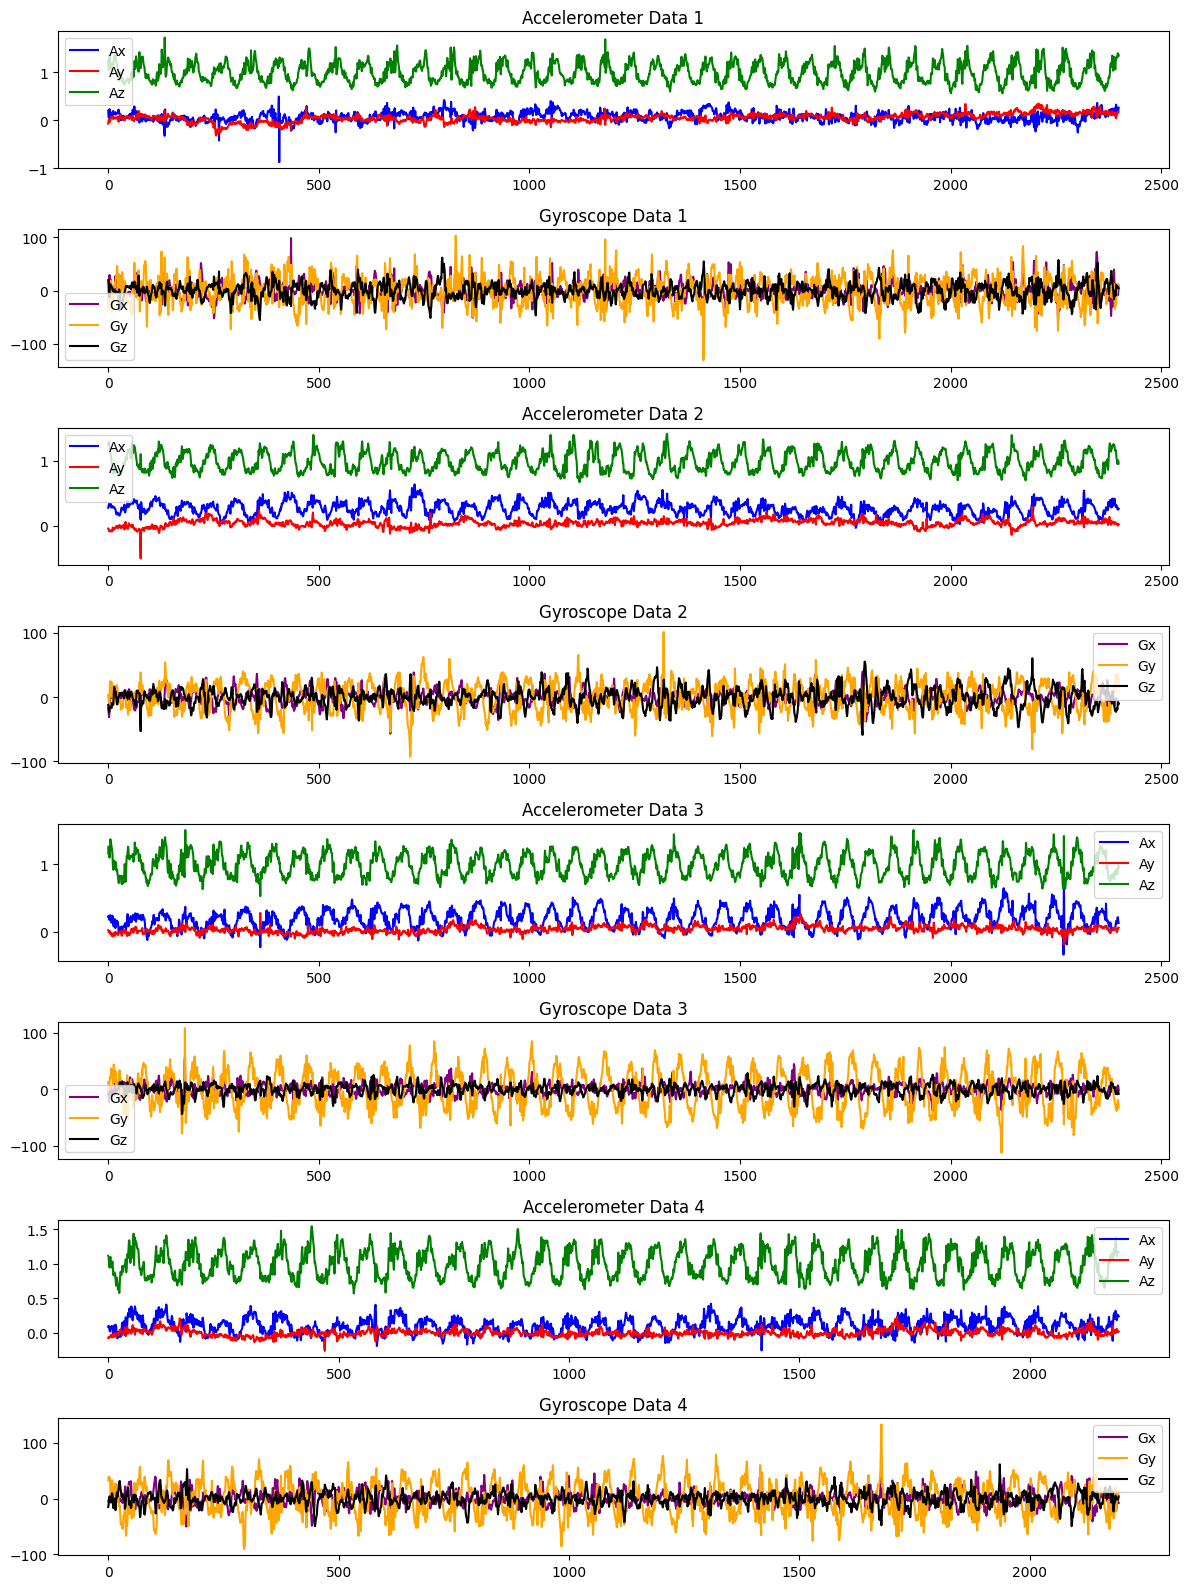

In [9]:
show_plots(df_vertical)

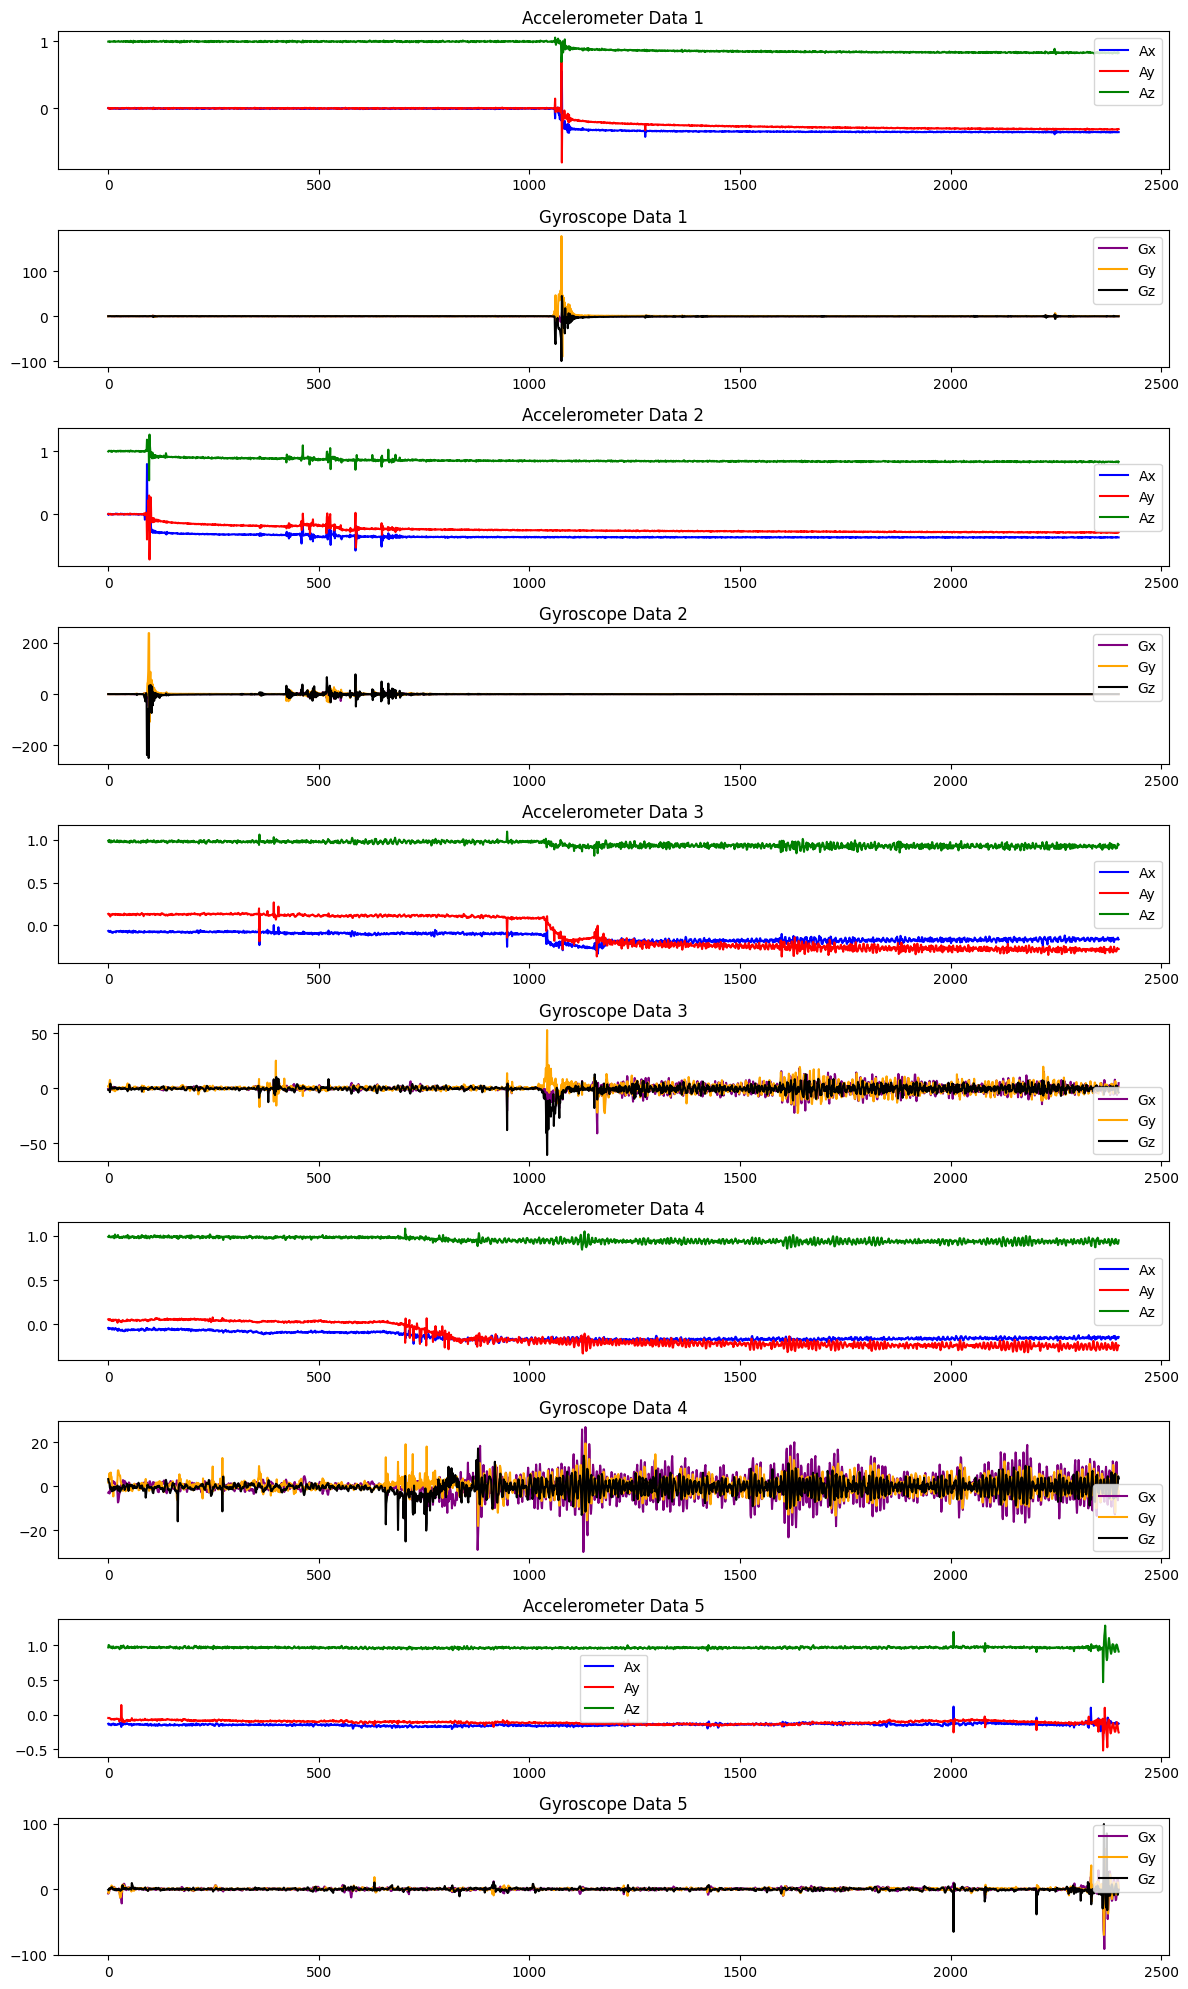

In [10]:
show_plots(df_still)

Horizontal data visualization.

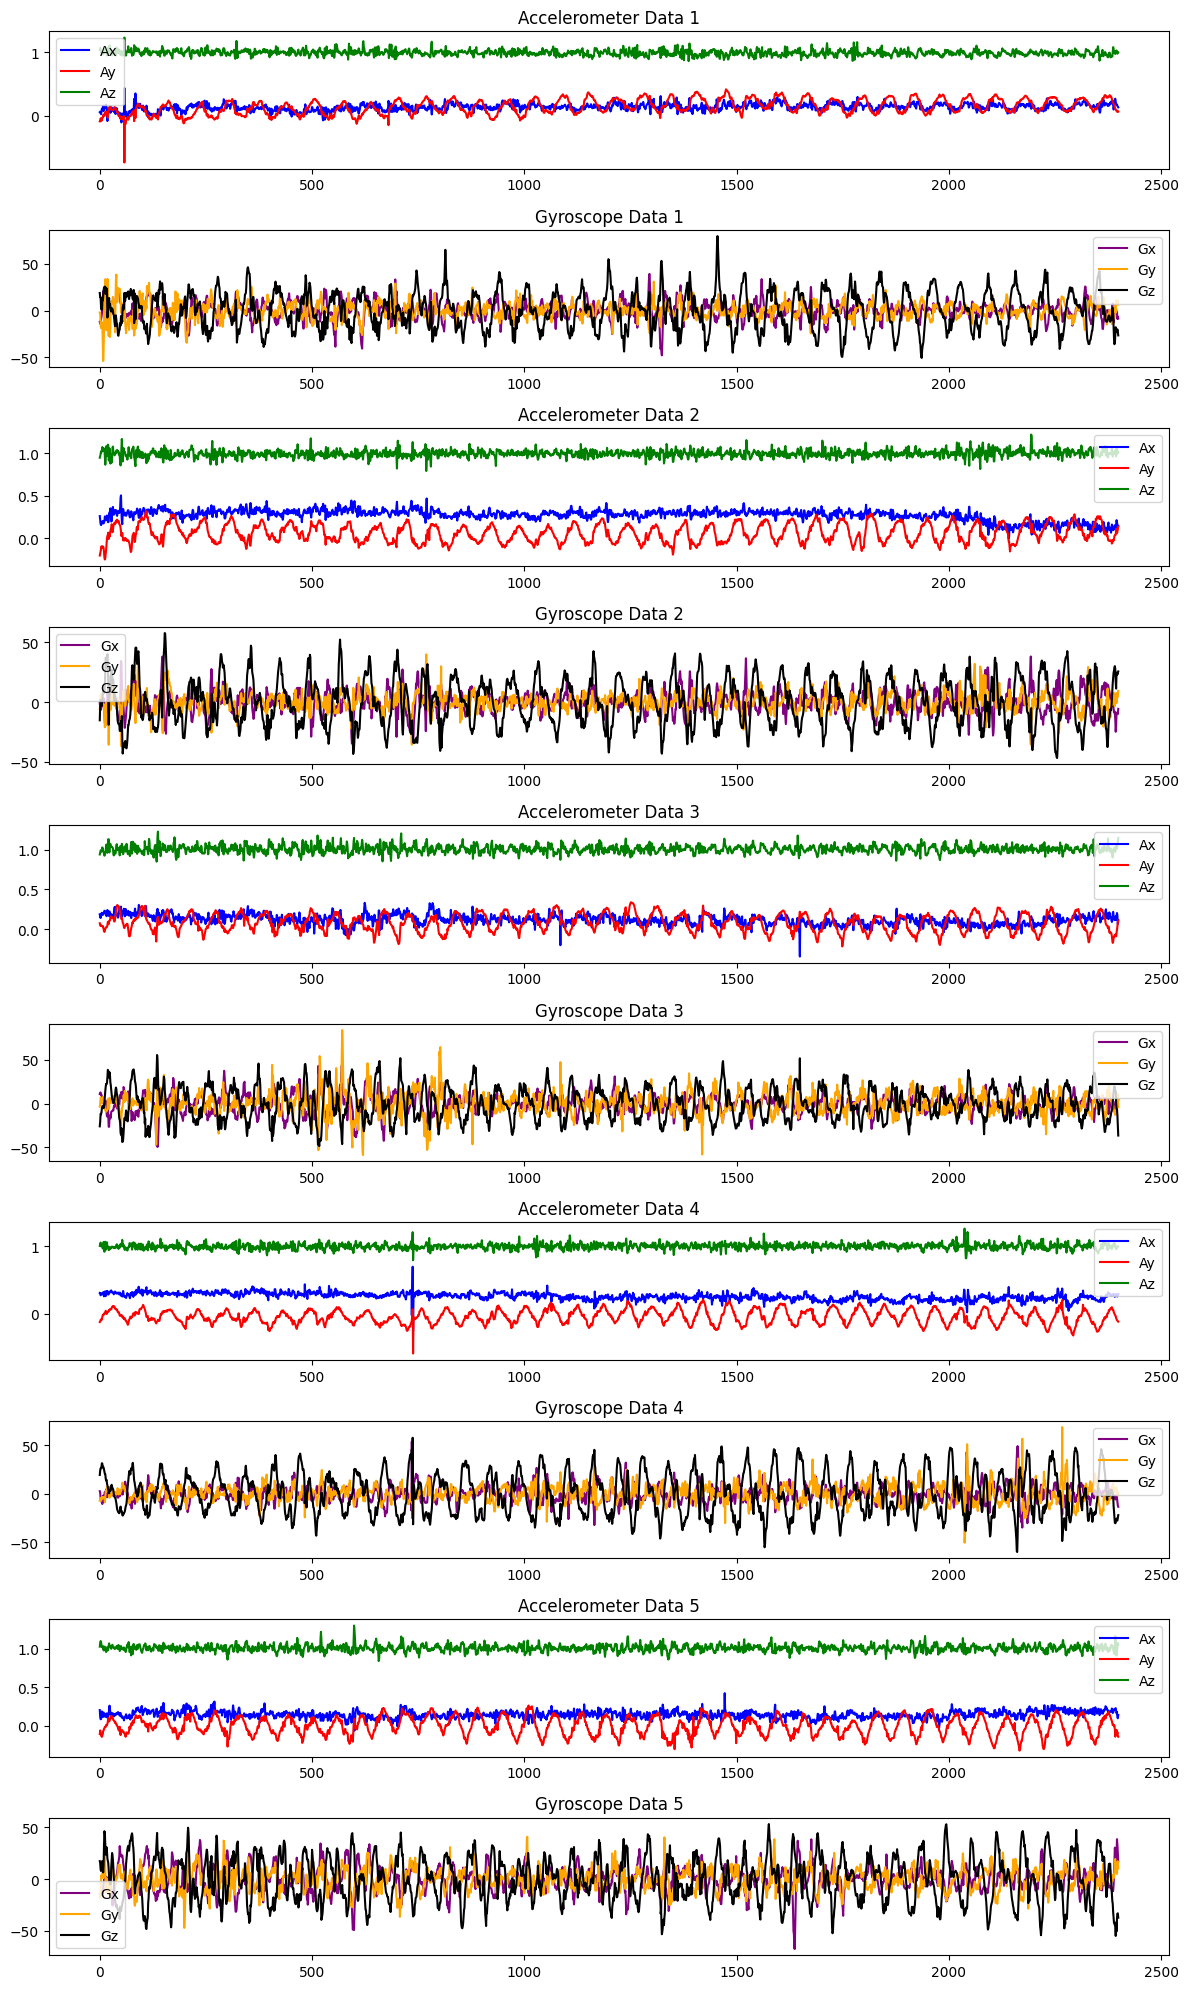

In [11]:
show_plots(df_horizontal)

In [12]:
def std(data):
    acc_keys = ['Ax', 'Ay', 'Az']
    gyro_keys = ['Gx', 'Gy', 'Gz']
    
    acc_std = {axis: np.std(data[axis]) for axis in acc_keys}
    gyro_std = {axis: np.std(data[axis]) for axis in gyro_keys}
    
    return acc_std, gyro_std


In [13]:
def std_plot(df_list, movement_type):
    num_datasets = len(df_list)
    _, axes = plt.subplots(num_datasets, 2, figsize=(12, 4 * num_datasets), sharex=False)

    for i, df in enumerate(df_list):
        acc_std, gyro_std = std(df)

        ax_acc = axes[i][0]
        ax_gyro = axes[i][1]

        ax_acc.bar(acc_std.keys(), acc_std.values(), color='blue')
        ax_acc.set_title(f'dataset {i+1}: std acc')

        ax_gyro.bar(gyro_std.keys(), gyro_std.values(), color='red')
        ax_gyro.set_title(f'dataset {i+1}: std gyro')

    plt.tight_layout()
    plt.suptitle(f'{movement_type} movement')
    plt.show()



Standard deviation plots for vertical movement.

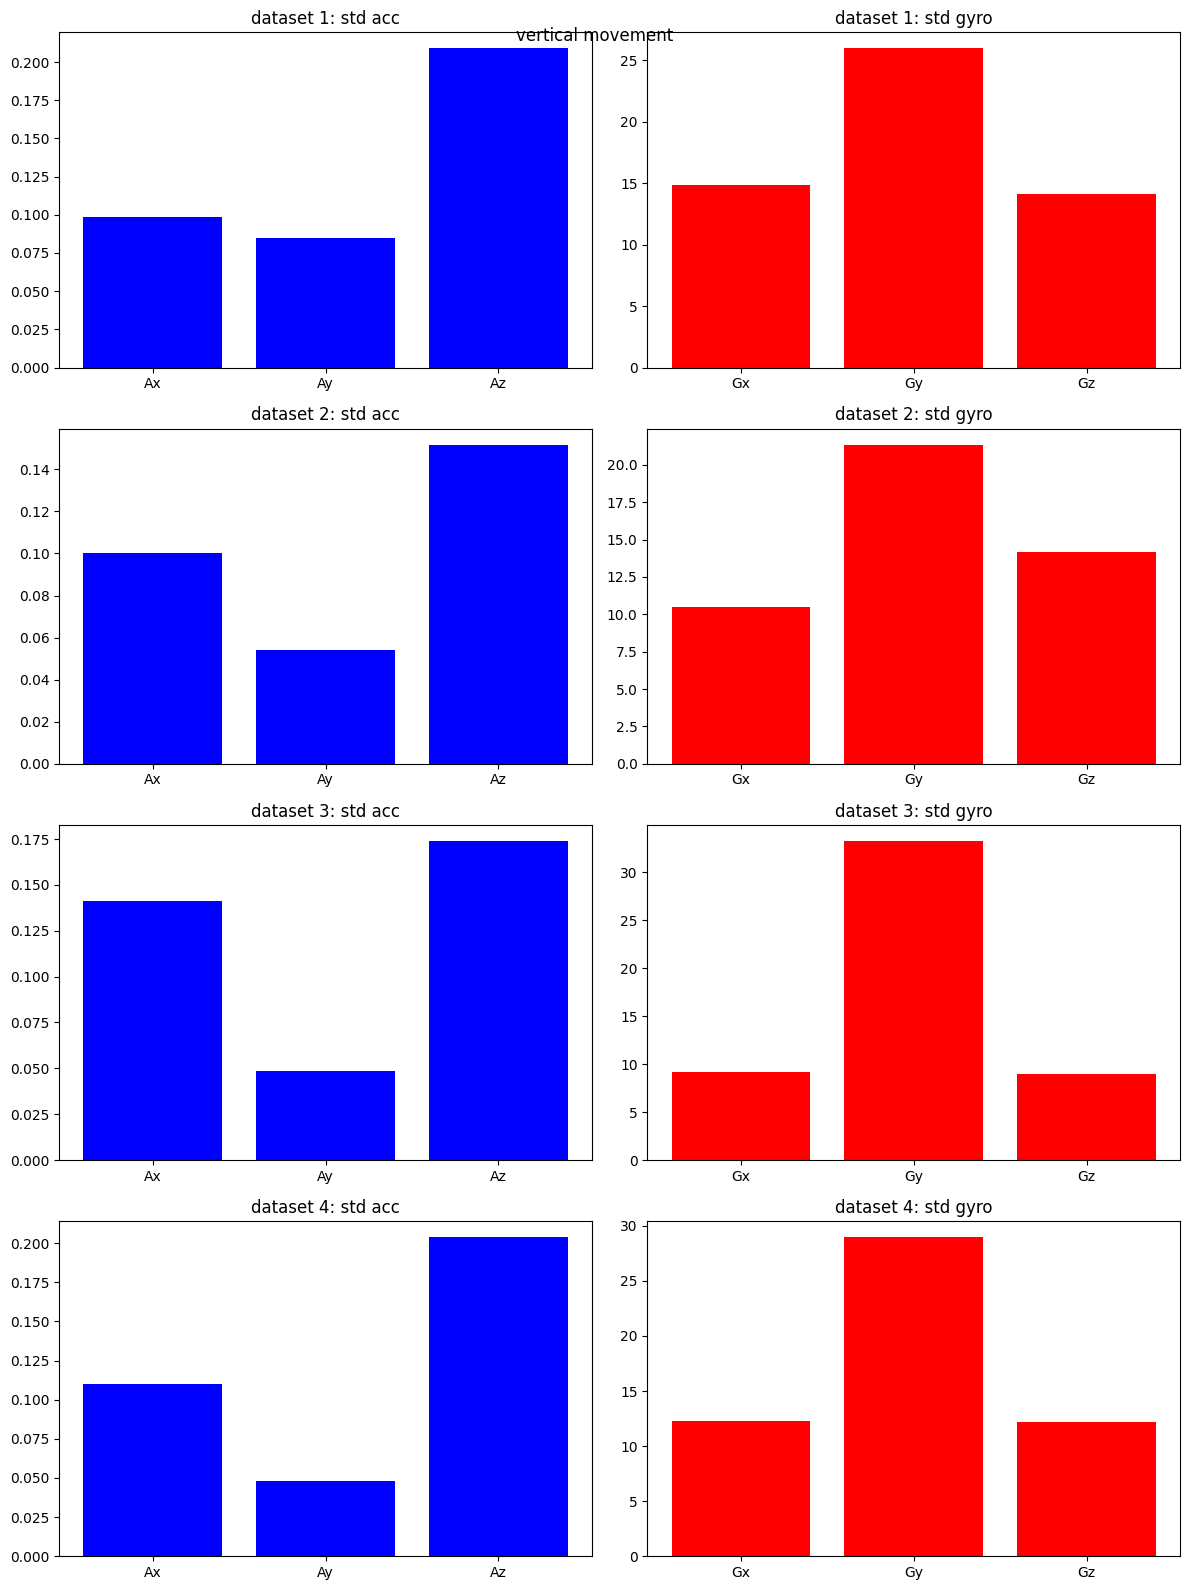

In [14]:
std_plot(df_vertical, 'vertical')

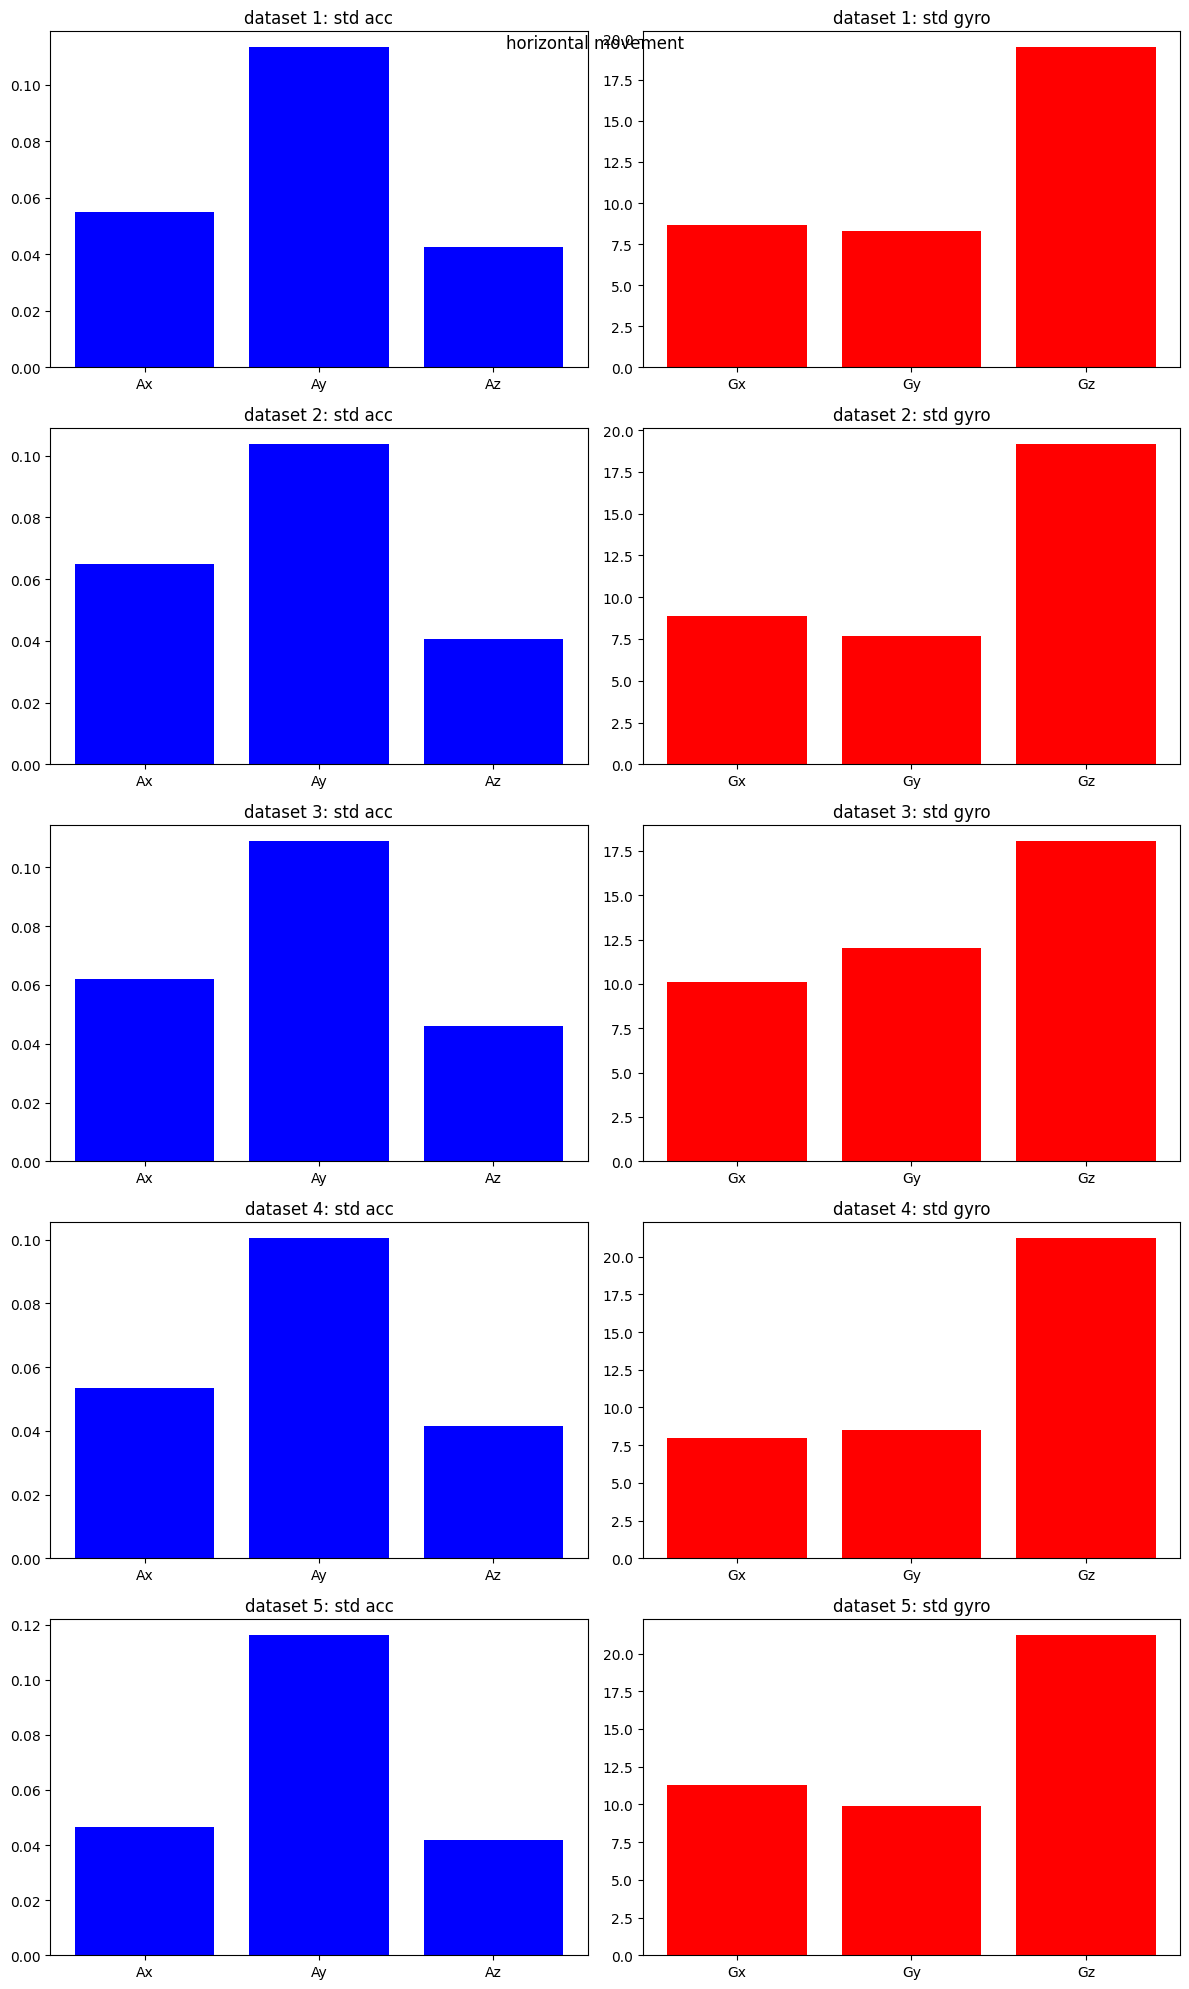

In [15]:
std_plot(df_horizontal, 'horizontal')